## 1. Opis problemu
Celem projektu było stworzenie sztucznej inteligencji (bota) do prostej, turowej gry bitewnej (RPG). Zamiast używać twardych, oskryptowanych instrukcji warunkowych, zdecydowano się na zastosowanie systemu wnioskowania opatego na logice rozmytej. Dzięki temu bot podejmuje decyzje taktyczne w sposób płynny, ważąc jednocześnie ryzyko, własne zasoby oraz szanse na pokonanie przeciwnika.

Bot analizuje sytuację na podstawie **4 zmiennych wejściowych**, w ramach których zdefiniowano łącznie **16 funkcji członkostwa (faktów)**. Następnie za pomocą zestawu reguł generowana jest **1 zmienna wyjściowa**, która decyduje o podjętej akcji.

### Zmienne wejściowe:
1. **Punkty zdrowia bota (`my_hp`)** – w skali [0 - 100].
2. **Punkty zdrowia wroga (`enemy_hp`)** – w skali [0 - 100].
3. **Punkty many/energii bota (`my_mana`)** – w skali [0 - 100] (potrzebne do leczenia i magii).
4. **Dystans do wroga (`distance`)** – w skali [0 - 100] metrów.

### Zmienna wyjściowa:
1. **Pula Akcji (`action`)** – w skali [0 - 100]. Wynikowa wartość wyostrzona (tzw. *crisp value*) jest rzutowana na konkretne zachowanie w grze:
   * 0 - 20: **Ucieczka** (Zbyt duże ryzyko, ratowanie się).
   * 20 - 40: **Obrona** (Blokowanie ciosów celem przeczekania).
   * 40 - 60: **Leczenie** (Odnowienie własnego HP za pomocą many).
   * 60 - 80: **Atak Wręcz** (Standardowy atak fizyczny na bliski dystans).
   * 80 - 100: **Atak Magiczny** (Potężny atak z dystansu używający many).

---

## 2. Definicja zbiorów rozmytych (Fakty)

Poniżej zdefiniowano 16 rozmytych funkcji członkostwa, co pozwala systemowi bardzo precyzyjnie modelować abstrakcyjne koncepcje:

* **Własne HP (`my_hp`) - 4 fakty:**
  * `Krytyczne` (0, 0, 10, 25)
  * `Niskie` (15, 30, 50)
  * `Srednie` (40, 60, 80)
  * `Wysokie` (70, 85, 100, 100)
* **HP Wroga (`enemy_hp`) - 4 fakty:**
  * `Krytyczne` (0, 0, 10, 25)
  * `Niskie` (15, 30, 50)
  * `Srednie` (40, 60, 80)
  * `Wysokie` (70, 85, 100, 100)
* **Własna Mana (`my_mana`) - 4 fakty:**
  * `Brak` (0, 0, 5, 15)
  * `Malo` (10, 25, 45)
  * `Srednio` (35, 60, 80)
  * `Duzo` (70, 85, 100, 100)
* **Dystans (`distance`) - 4 fakty:**
  * `Zwarcie` (0, 0, 10, 20)
  * `Blisko` (10, 25, 45)
  * `Srednio` (35, 55, 75)
  * `Daleko` (65, 85, 100, 100)

Dla zmiennej wyjściowej `action` przypisano 5 funkcji odpowiadających docelowym zachowaniom (odpowiednio: Ucieczka, Obrona, Leczenie, AtakWrecz, AtakMagiczny).

---

## 3. Baza reguł taktycznych

Stworzono bazę **10 reguł taktycznych** definiujących zachowanie AI:
1. JEŚLI własne HP to `Krytyczne` ORAZ mana to `Duzo`, WNIOSEK akcja to `Leczenie` *(ratowanie życia).*
2. JEŚLI własne HP to `Krytyczne` ORAZ mana to `Brak`, WNIOSEK akcja to `Ucieczka` *(nie ma szans na ratunek, trzeba uciekać).*
3. JEŚLI HP wroga to `Krytyczne` ORAZ dystans to `Zwarcie`, WNIOSEK akcja to `AtakWrecz` *(szybkie dobicie wroga wręcz).*
4. JEŚLI HP wroga to `Krytyczne` ORAZ dystans to `Daleko`, WNIOSEK akcja to `AtakMagiczny` *(dobij wroga z bezpiecznego dystansu).*
5. JEŚLI własne HP to `Niskie` ORAZ HP wroga to `Wysokie`, WNIOSEK akcja to `Obrona` *(minimalizowanie obrażeń od przeważającego przeciwnika).*
6. JEŚLI mana to `Brak` ORAZ dystans to `Daleko`, WNIOSEK akcja to `Ucieczka` *(bezużyteczność na dystans, lepiej uciec).*
7. JEŚLI dystans to `Blisko` ORAZ mana to `Malo`, WNIOSEK akcja to `AtakWrecz` *(oszczędzanie resztek magii).*
8. JEŚLI własne HP to `Wysokie` ORAZ HP wroga to `Wysokie` ORAZ mana to `Duzo`, WNIOSEK akcja to `AtakMagiczny` *(ofensywne otwarcie walki).*
9. JEŚLI dystans to `Srednio` ORAZ mana to `Srednio`, WNIOSEK akcja to `AtakMagiczny` *(nurt taktyczny dystansowy).*
10. JEŚLI własne HP to `Srednie` ORAZ HP wroga to `Niskie` ORAZ dystans to `Zwarcie`, WNIOSEK akcja to `AtakWrecz` *(bezpieczna przewaga nad wrogiem w zwarciu).*

---

## 4. Implementacja:

In [1]:
!pip install simpful

In [2]:
from simpful import *

In [3]:
FS = FuzzySystem()

  ____  __  _  _  ____  ____  _  _  __   
 / ___)(  )( \/ )(  _ \(  __)/ )( \(  ) v2.12.0 
 \___ \ )( / \/ \ ) __/ ) _) ) \/ (/ (_/\ 
 (____/(__)\_)(_/(__)  (__)  \____/\____/

 https://github.com/aresio/simpful



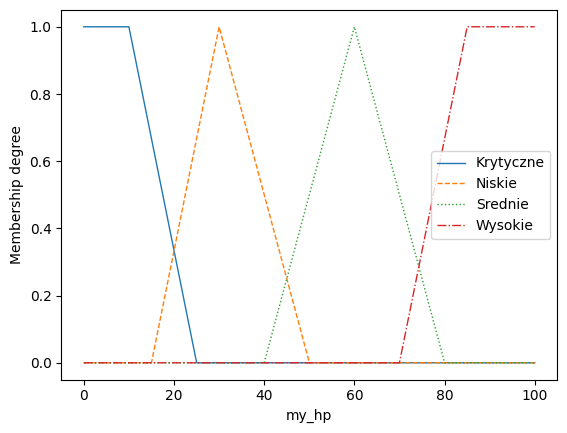

In [4]:
# ZMIENNA 1: Własne HP (0-100)
hp_1 = TrapezoidFuzzySet(a=0, b=0, c=10, d=25, term="Krytyczne")
hp_2 = TriangleFuzzySet(a=15, b=30, c=50, term="Niskie")
hp_3 = TriangleFuzzySet(a=40, b=60, c=80, term="Srednie")
hp_4 = TrapezoidFuzzySet(a=70, b=85, c=100, d=100, term="Wysokie")
FS.add_linguistic_variable("my_hp", LinguisticVariable([hp_1, hp_2, hp_3, hp_4], universe_of_discourse=[0, 100]))
FS.plot_variable("my_hp")

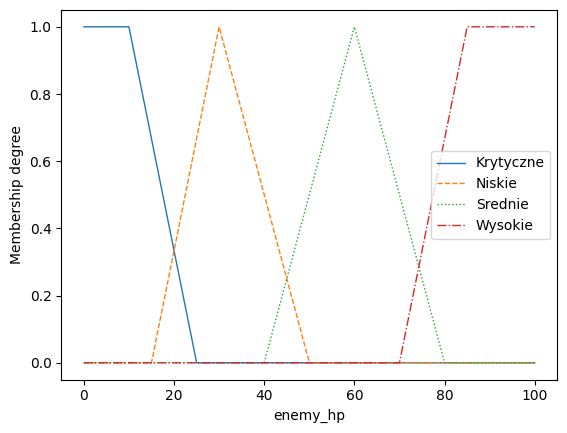

In [5]:
# ZMIENNA 2: HP Wroga (0-100)
ehp_1 = TrapezoidFuzzySet(a=0, b=0, c=10, d=25, term="Krytyczne")
ehp_2 = TriangleFuzzySet(a=15, b=30, c=50, term="Niskie")
ehp_3 = TriangleFuzzySet(a=40, b=60, c=80, term="Srednie")
ehp_4 = TrapezoidFuzzySet(a=70, b=85, c=100, d=100, term="Wysokie")
FS.add_linguistic_variable("enemy_hp", LinguisticVariable([ehp_1, ehp_2, ehp_3, ehp_4], universe_of_discourse=[0, 100]))
FS.plot_variable("enemy_hp")

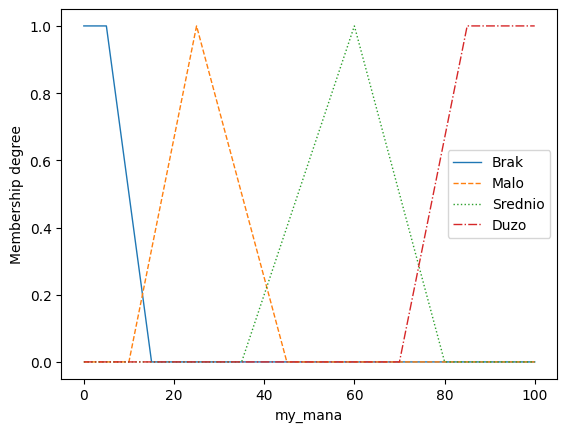

In [6]:
# ZMIENNA 3: Własna Mana (0-100)
mn_1 = TrapezoidFuzzySet(a=0, b=0, c=5, d=15, term="Brak")
mn_2 = TriangleFuzzySet(a=10, b=25, c=45, term="Malo")
mn_3 = TriangleFuzzySet(a=35, b=60, c=80, term="Srednio")
mn_4 = TrapezoidFuzzySet(a=70, b=85, c=100, d=100, term="Duzo")
FS.add_linguistic_variable("my_mana", LinguisticVariable([mn_1, mn_2, mn_3, mn_4], universe_of_discourse=[0, 100]))
FS.plot_variable("my_mana")

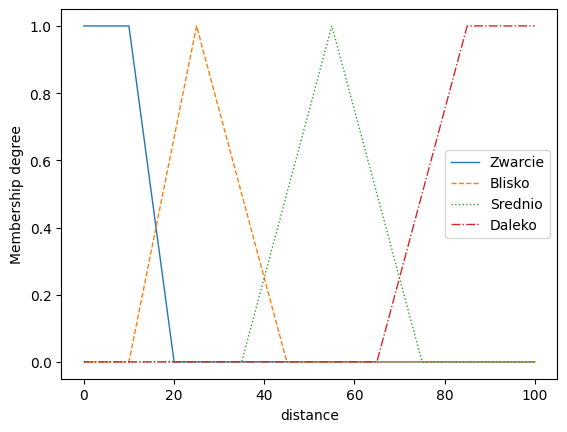

In [7]:
# ZMIENNA 4: Dystans do wroga (0-100)
d_1 = TrapezoidFuzzySet(a=0, b=0, c=10, d=20, term="Zwarcie")
d_2 = TriangleFuzzySet(a=10, b=25, c=45, term="Blisko")
d_3 = TriangleFuzzySet(a=35, b=55, c=75, term="Srednio")
d_4 = TrapezoidFuzzySet(a=65, b=85, c=100, d=100, term="Daleko")
FS.add_linguistic_variable("distance", LinguisticVariable([d_1, d_2, d_3, d_4], universe_of_discourse=[0, 100]))
FS.plot_variable("distance")

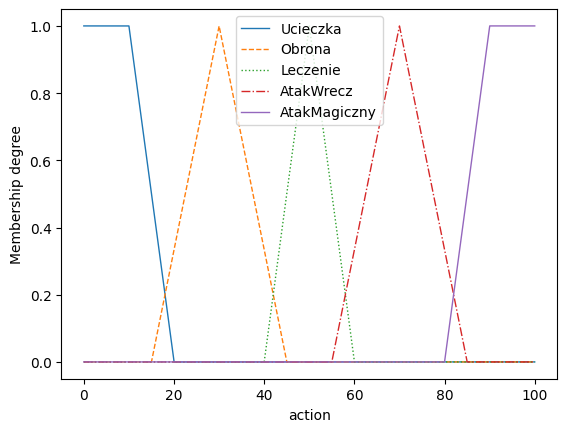

In [8]:
# ZMIENNA WYJŚCIOWA (0-100) - Akcja
act_1 = TrapezoidFuzzySet(a=0, b=0, c=10, d=20, term="Ucieczka")
act_2 = TriangleFuzzySet(a=15, b=30, c=45, term="Obrona")
act_3 = TriangleFuzzySet(a=40, b=50, c=60, term="Leczenie")
act_4 = TriangleFuzzySet(a=55, b=70, c=85, term="AtakWrecz")
act_5 = TrapezoidFuzzySet(a=80, b=90, c=100, d=100, term="AtakMagiczny")
FS.add_linguistic_variable("action", LinguisticVariable([act_1, act_2, act_3, act_4, act_5], universe_of_discourse=[0, 100]))
FS.plot_variable("action")

In [9]:
rules =[
    "IF (my_hp IS Krytyczne) AND (my_mana IS Duzo) THEN (action IS Leczenie)",
    "IF (my_hp IS Krytyczne) AND (my_mana IS Brak) THEN (action IS Ucieczka)",
    "IF (enemy_hp IS Krytyczne) AND (distance IS Zwarcie) THEN (action IS AtakWrecz)",
    "IF (enemy_hp IS Krytyczne) AND (distance IS Daleko) THEN (action IS AtakMagiczny)",
    "IF (my_hp IS Niskie) AND (enemy_hp IS Wysokie) THEN (action IS Obrona)",
    "IF (my_mana IS Brak) AND (distance IS Daleko) THEN (action IS Ucieczka)",
    "IF (distance IS Blisko) AND (my_mana IS Malo) THEN (action IS AtakWrecz)",
    "IF (my_hp IS Wysokie) AND (enemy_hp IS Wysokie) AND (my_mana IS Duzo) THEN (action IS AtakMagiczny)",
    "IF (distance IS Srednio) AND (my_mana IS Srednio) THEN (action IS AtakMagiczny)",
    "IF (my_hp IS Srednie) AND (enemy_hp IS Niskie) AND (distance IS Zwarcie) THEN (action IS AtakWrecz)"
]
FS.add_rules(rules)

In [10]:
# Sytuacja testowa:
# W pomieszczeniu jest dość ciepło (26°C), duża wilgotność (75%),
# jest sporo ludzi (12 osób), a na zewnątrz jest upał (33°C).
FS.set_variable("my_hp", 12)
FS.set_variable("enemy_hp", 60)
FS.set_variable("my_mana", 90)
FS.set_variable("distance", 50)

In [11]:
result = FS.inference()
action_score = result['action']

def get_action_name(score):
    if score <= 20: return "Ucieczka"
    elif score <= 40: return "Obrona"
    elif score <= 60: return "Leczenie"
    elif score <= 80: return "Atak Wręcz"
    else: return "Atak Magiczny"

print("--- DECYZJA BOTA RPG ---")
print(f"Moje HP: 12, HP Wroga: 60, Moja Mana: 90, Dystans: 50m")
print(f"Surowy wynik systemu rozmytego (0-100): {action_score:.2f}")
print(f"Zinterpretowana akcja Bota: >> {get_action_name(action_score)} <<")

--- DECYZJA BOTA RPG ---
Moje HP: 12, HP Wroga: 60, Moja Mana: 90, Dystans: 50m
Surowy wynik systemu rozmytego (0-100): 50.00
Zinterpretowana akcja Bota: >> Leczenie <<


---
## 5. Podsumowanie i Wnioski

Jak pokazał wynik testowego scenariusza, bot mając 12 HP uznał swoją sytuację za Krytyczną. Widząc jednak, że posiada aż 90 punktów Many (fakt Dużo), system rozmyty silnie odpalił regułę nr 1. Zmienna wyjściowa osiągnęła wartość oscylującą w okolicy 50.0, co idealnie mapuje się na akcję Leczenie. Gdyby bot nie posiadał many (Mana = 0), uruchomiłaby się reguła nr 2, a wynik wskazałby na wartość w okolicy 10.0, zmuszając postać do Ucieczki.
Zastosowanie zbiorów rozmytych eliminuje częsty w prostych grach problem z "drganiem decyzyjnym" i czyni bota inteligentnym na poziomie adaptacji do złożonych, nakładających się na siebie sytuacji na polu walki.